In [4]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,Annotated
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage,HumanMessage 
from langgraph.checkpoint.memory import InMemorySaver

In [21]:
model = ChatOllama(model='qwen2.5:3b',temperature=0.5)

In [22]:
class jokeState(TypedDict) : 
    topic : str 
    joke : str 
    explanation : str 

In [23]:
def generate_joke(state: jokeState ) : 
    messages = [SystemMessage(content="You are a very funny person with a very good sense of humour."),
                HumanMessage(content=f"your task is to generate a joke on topic {state['topic']}")]
    response = model.invoke(messages).content
    return {'joke':response}

In [24]:
def generate_explanation(state:jokeState) : 
    prompt = f"write an explanation for the joke \n {state['joke']} "
    response = model.invoke(prompt).content
    return {'explanation':response}

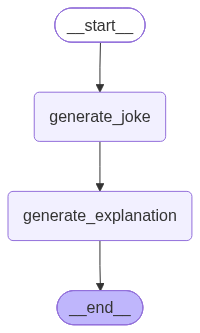

In [25]:
graph = StateGraph(jokeState) 
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)
checkPointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkPointer)
workflow

In [35]:
config1 =  {"configurable":{"thread_id":"2"}}
final_state = workflow.invoke({"topic":"pasta"},config=config1)
final_state

{'topic': 'pasta',
 'joke': "Sure, here's a pasta-themed joke for you:\n\nWhy did the tomato turn red?\n\nBecause it saw the salad dressing!\n\nNow, let's see if you can crack the code!",
 'explanation': "This joke plays on the imagery and the typical order of events in cooking. The tomato is a common ingredient used in salads, and it's well-known that tomatoes tend to change color from green to red as they ripen. The punchline suggests that the tomato, being able to see, observed the salad dressing, which is often red, and thus decided to change its own color to match. This play on words is humorous because it combines the idea of food preparation with a human-like perspective, making the tomato appear to be aware and making a choice, which is a common element in jokes meant to be amusing and unexpected."}

In [36]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'pasta', 'joke': "Sure, here's a pasta-themed joke for you:\n\nWhy did the tomato turn red?\n\nBecause it saw the salad dressing!\n\nNow, let's see if you can crack the code!", 'explanation': "This joke plays on the imagery and the typical order of events in cooking. The tomato is a common ingredient used in salads, and it's well-known that tomatoes tend to change color from green to red as they ripen. The punchline suggests that the tomato, being able to see, observed the salad dressing, which is often red, and thus decided to change its own color to match. This play on words is humorous because it combines the idea of food preparation with a human-like perspective, making the tomato appear to be aware and making a choice, which is a common element in jokes meant to be amusing and unexpected."}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1c1a6d-3ee2-6404-8006-81a00db245df'}}, metadata={'source': 'loop', '

In [37]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pasta', 'joke': "Sure, here's a pasta-themed joke for you:\n\nWhy did the tomato turn red?\n\nBecause it saw the salad dressing!\n\nNow, let's see if you can crack the code!", 'explanation': "This joke plays on the imagery and the typical order of events in cooking. The tomato is a common ingredient used in salads, and it's well-known that tomatoes tend to change color from green to red as they ripen. The punchline suggests that the tomato, being able to see, observed the salad dressing, which is often red, and thus decided to change its own color to match. This play on words is humorous because it combines the idea of food preparation with a human-like perspective, making the tomato appear to be aware and making a choice, which is a common element in jokes meant to be amusing and unexpected."}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1c1a6d-3ee2-6404-8006-81a00db245df'}}, metadata={'source': 'loop', 

## Time Travel

In [38]:
workflow.get_state({"configurable":{"thread_id":2,"checkpoint_id":"1f1c1a6b-77fd-6c90-8000-568bb8e4db58"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f1c1a6b-77fd-6c90-8000-568bb8e4db58'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-10-06T16:55:21.253782+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1c1a6b-77e7-6b84-bfff-927ca05faff1'}}, tasks=(PregelTask(id='11492e9a-9e9d-536f-147a-415fbbd8ab77', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Sure, here’s a pizza joke for you:\n\nWhy did the pizza cross the road?\n\nTo get out of that awful interview! \n\n(Although, in reality, pizzas don’t cross roads, but they sure can make for some great stories, don’t they?)'}),), interrupts=())

In [39]:
workflow.invoke(None,{"configurable":{"thread_id":2,"checkpoint_id":"1f1c1a6b-77fd-6c90-8000-568bb8e4db58"}})


{'topic': 'pizza',
 'joke': 'Sure, here’s a pizza joke for you! \n\nWhy did the pizza cross the road?\n\nTo get out of the margarine! \n\n(That\'s a play on the classic "Why did the chicken cross the road?" but with a twist involving margarine, which is often spread on pizza, and the word "margarine" sounds like "margarita" - a type of pizza topping.) \n\nHope you found that cheesy and funny!',
 'explanation': 'Certainly! Let\'s break down the pizza joke you shared:\n\n### The Joke: "Why did the pizza cross the road?"\n\n**Answer:** To get out of the margarine!\n\n### Explanation:\n\nThis joke plays on a few different elements, combining a classic setup with a bit of wordplay and culinary references. Here’s a breakdown of how it works:\n\n1. **Classic Setup:**\n   - The joke begins with the common setup, "Why did the chicken cross the road?" This is a well-known joke that has been around for a long time, often used as a setup for a punchline.\n\n2. **Wordplay and Culinary References:**

In [40]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Sure, here’s a pizza joke for you! \n\nWhy did the pizza cross the road?\n\nTo get out of the margarine! \n\n(That\'s a play on the classic "Why did the chicken cross the road?" but with a twist involving margarine, which is often spread on pizza, and the word "margarine" sounds like "margarita" - a type of pizza topping.) \n\nHope you found that cheesy and funny!', 'explanation': 'Certainly! Let\'s break down the pizza joke you shared:\n\n### The Joke: "Why did the pizza cross the road?"\n\n**Answer:** To get out of the margarine!\n\n### Explanation:\n\nThis joke plays on a few different elements, combining a classic setup with a bit of wordplay and culinary references. Here’s a breakdown of how it works:\n\n1. **Classic Setup:**\n   - The joke begins with the common setup, "Why did the chicken cross the road?" This is a well-known joke that has been around for a long time, often used as a setup for a punchline.\n\n2. **Wordplay and Cu

## Update State

In [44]:
workflow.update_state({"configurable":{"thread_id":2,'checkpoint_ns': '',"checkpoint_id":"1f1c1a6b-77fd-6c90-8000-568bb8e4db58"}},{"topic":"samosa"})


{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1c1acc-c4d3-65f4-8001-be71b1b4f500'}}

In [45]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1c1acc-c4d3-65f4-8001-be71b1b4f500'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-10-06T17:38:53.134359+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1c1a6b-77fd-6c90-8000-568bb8e4db58'}}, tasks=(PregelTask(id='7779edd5-f9e9-a93e-f604-de1c942bd63c', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Sure, here’s a pizza joke for you! \n\nWhy did the pizza cross the road?\n\nTo get out of the margarine! \n\n(That\'s a play on the classic "Why did the chicken cross the road?" but with a twist involving margarine, which is often spread on pizza, and the word "margarine" sounds like "margarita" - a type of pizza topping.) \n\nH

In [47]:
workflow.invoke(None,{"configurable":{"thread_id":2,'checkpoint_ns': '',"checkpoint_id":"1f1c1acc-c4d3-65f4-8001-be71b1b4f500"}})

{'topic': 'samosa',
 'joke': 'Sure, here\'s a samosa-themed joke for you! \n\nWhy did the samosa decide to go to therapy?\n\nBecause it had a lot of "gut issues" and was feeling a bit "stuffed" with stress! \n\nI hope you found that one a bit savory and a bit spicy!',
 'explanation': 'The joke I provided is a play on words and a bit of a pun, incorporating elements from a popular Indian pastry called the samosa. Here\'s a breakdown of the joke:\n\n1. **Samosa**: It\'s a savory pastry filled with spiced potatoes, peas, and sometimes meat, and is often eaten as a snack or appetizer.\n\n2. **"Gut issues"**: This is a colloquial term that refers to digestive issues or problems, which is a common concern for many people.\n\n3. **"Stuffed"**: In the context of food, it means the pastry is filled with a lot of filling. Here, it can also mean feeling overwhelmed or burdened by stress.\n\nThe joke plays on these terms in a humorous way. The samosa is making a joke about its own digestive issues

In [48]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Sure, here\'s a samosa-themed joke for you! \n\nWhy did the samosa decide to go to therapy?\n\nBecause it had a lot of "gut issues" and was feeling a bit "stuffed" with stress! \n\nI hope you found that one a bit savory and a bit spicy!', 'explanation': 'The joke I provided is a play on words and a bit of a pun, incorporating elements from a popular Indian pastry called the samosa. Here\'s a breakdown of the joke:\n\n1. **Samosa**: It\'s a savory pastry filled with spiced potatoes, peas, and sometimes meat, and is often eaten as a snack or appetizer.\n\n2. **"Gut issues"**: This is a colloquial term that refers to digestive issues or problems, which is a common concern for many people.\n\n3. **"Stuffed"**: In the context of food, it means the pastry is filled with a lot of filling. Here, it can also mean feeling overwhelmed or burdened by stress.\n\nThe joke plays on these terms in a humorous way. The samosa is making a joke about its 